In [149]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

%matplotlib inline
sns.set_style('whitegrid')

## Display options

In [150]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [151]:
from pathlib import Path
import pandas as pd

def get_data_path(filename):
    return Path().resolve().parent / 'input' / filename




df = pd.read_csv(get_data_path('train.csv'))



df.head()


## fare std is 50 and mean is 32
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [152]:
# first look at the data

print(df.shape,end='\n\n')      
print(df.dtypes,end='\n\n')     

df.isnull().sum()


(891, 12)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [153]:

missing  = df.isnull().sum()
missin_pct = (missing/len(df)) * 100


missing_df  = pd.DataFrame({
    'Missing' : missing,
    'Percent' : missin_pct
}).sort_values('Percent',ascending=False)


print(missing_df[missing_df['Missing'] > 0])





          Missing    Percent
Cabin         687  77.104377
Age           177  19.865320
Embarked        2   0.224467


In [154]:
# check reason why there are missing values in age column



df[df['Age'].isnull()]['Pclass'].value_counts()

Pclass
3    136
1     30
2     11
Name: count, dtype: int64

In [155]:
# we see that the Cabin,Age,Fare have missing values




# Cabin
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)

df['Cabin'] = df['Cabin'].fillna('Unknown')



# Age
num_inputer  = SimpleImputer(strategy="median")

df['Age'] = num_inputer.fit_transform(df[['Age']])
df['Fare'] = num_inputer.fit_transform(df[['Fare']])












<Axes: >

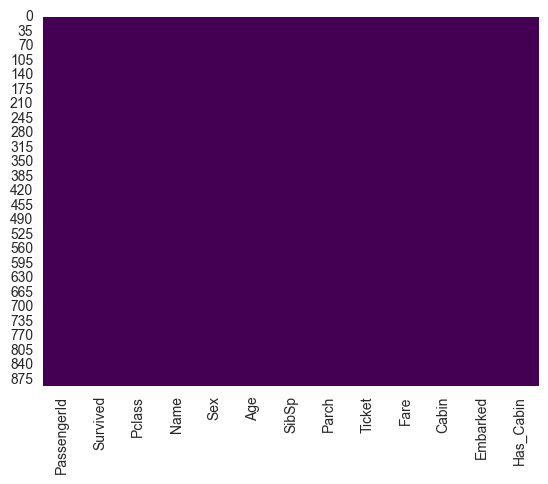

In [156]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis') # visualize missing values

# Univariate Analysis

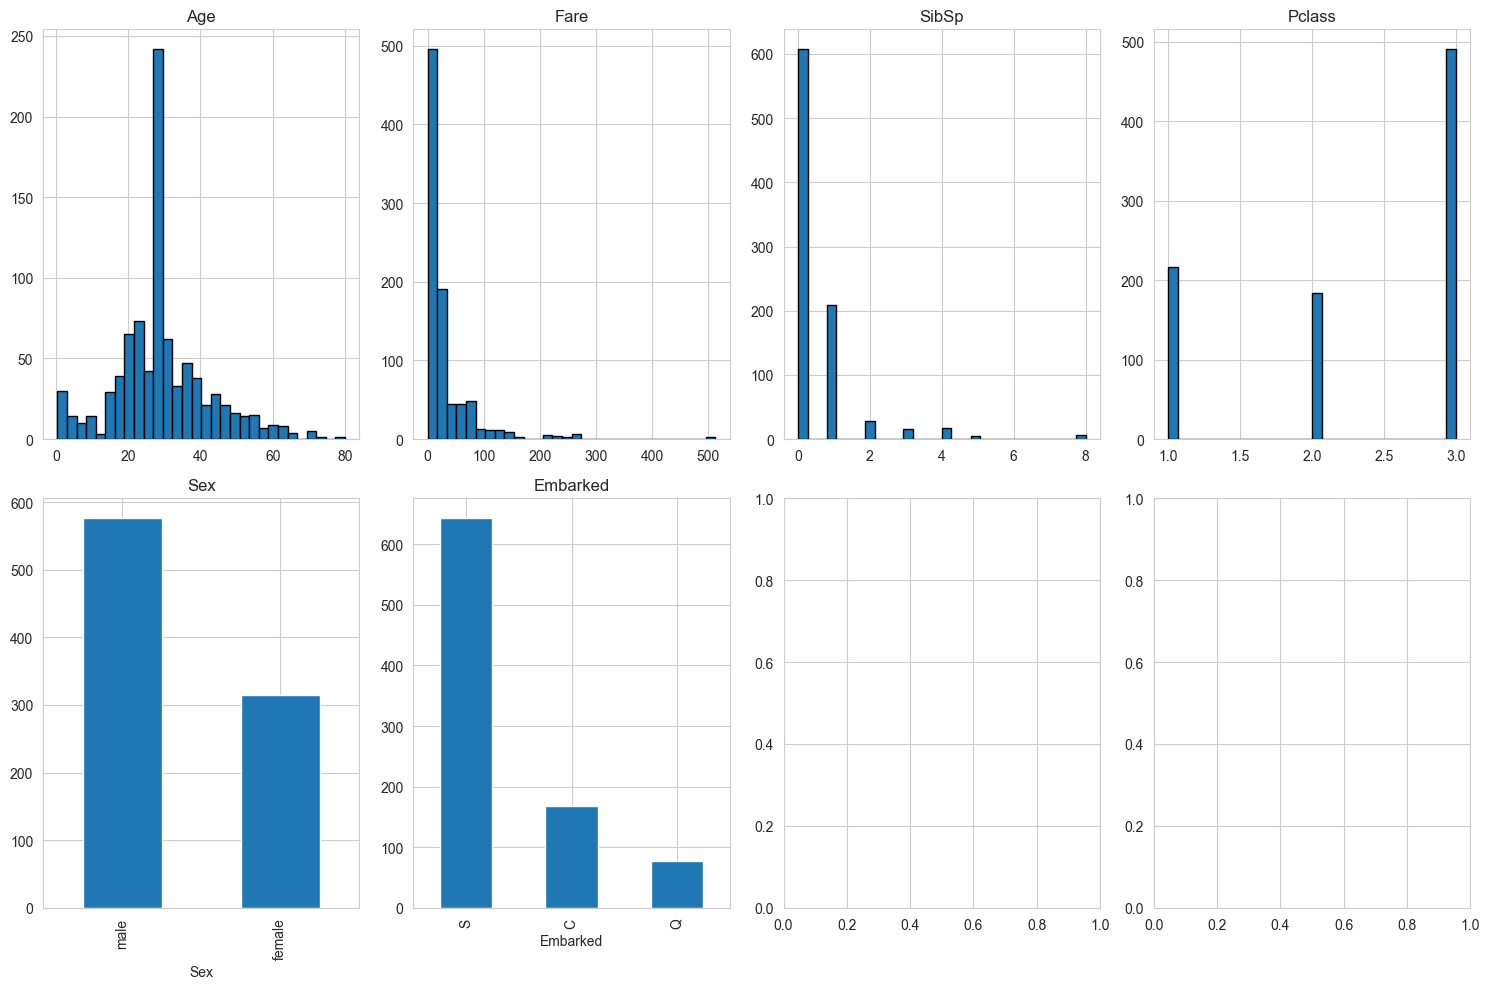

In [157]:
fig, axes = plt.subplots(2, 4, figsize=(15, 10))

for i, col in enumerate(['Age','Fare','SibSp','Pclass']):
    df[col].hist(ax=axes[0,i],bins=30,edgecolor='k')
    axes[0,i].set_title(col)


for i, col in enumerate(['Sex','Embarked']):
    df[col].value_counts().plot(kind="bar",ax=axes[1,i])
    axes[1,i].set_title(col)
    

plt.tight_layout()

In [158]:
df['Fare_log'] = np.log1p(df['Fare']) #TODO feature engineering of the data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_Cabin,Fare_log
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,0,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C,1,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,0,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,3.990834
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,0,2.202765


# Bivariate Analysis

C:\Users\denis\AppData\Local\Temp\ipykernel_12564\1132641913.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Survived', y='Age', palette='coolwarm')


<Axes: title={'center': 'Survival rate by Sex & Class'}>

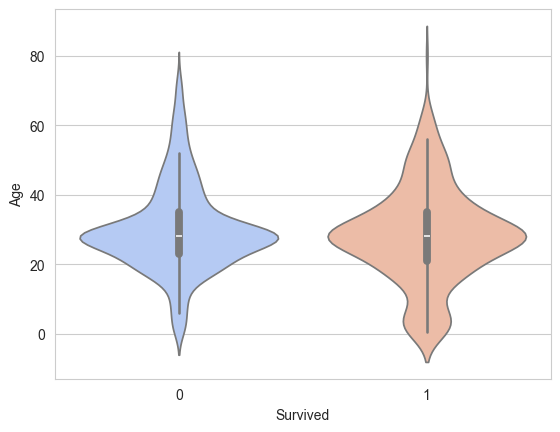

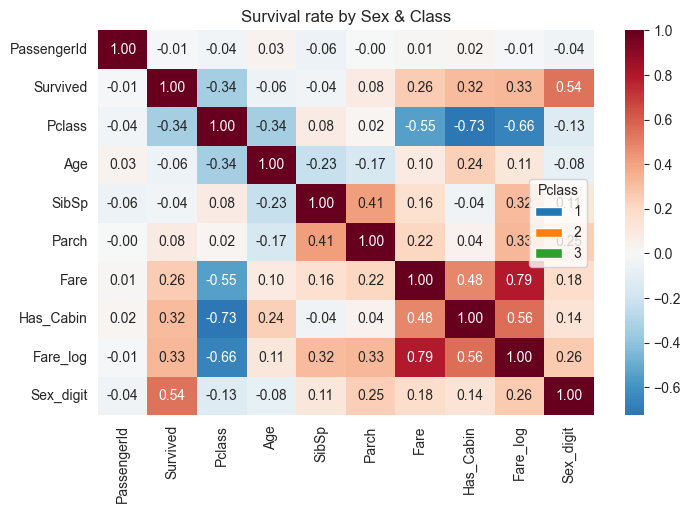

In [159]:
sns.violinplot(data=df, x='Survived', y='Age', palette='coolwarm')

df['Sex_digit'] = df['Sex'].map({'female': 1, 'male': 0})


survival_rate = df.groupby(['Sex', 'Pclass',])['Survived'].mean().unstack()
survival_rate.plot(kind='bar', figsize=(8, 5))
plt.title('Survival rate by Sex & Class')


corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')






# feature engineering

<Figure size 640x480 with 0 Axes>

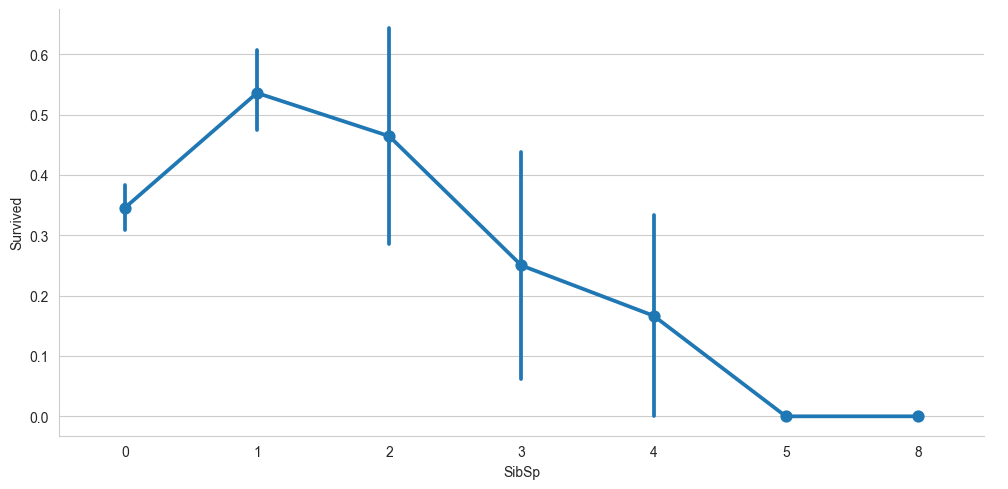

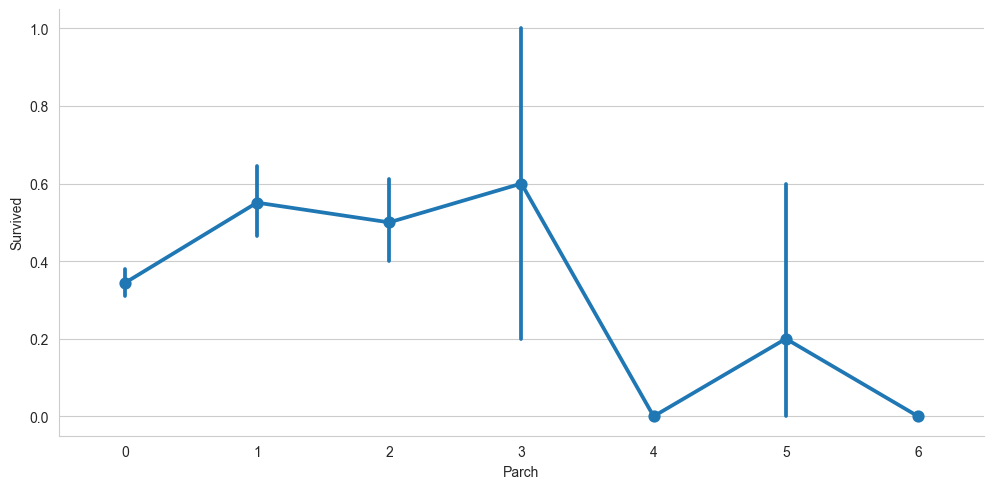

In [160]:
# check reason group SibSp and Parch 


for i, col in enumerate(['SibSp','Parch']):
    plt.figure(i)
    sns.catplot(x=col, y='Survived', data=df, kind='point',aspect=2)



In [161]:
from ml_project.feature_engineering import feature_engineering

df = feature_engineering(df)


df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_Cabin,Fare_log,Sex_digit,FamilySize,IsAlone,Title,AgeBand,PclassGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,0,2.110213,0,2,0,Mr,Adult,3rd Class
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C,1,4.280593,1,2,0,Mrs,Middle,1st Class
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,0,2.188856,1,1,1,Miss,Adult,3rd Class
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,3.990834,1,2,0,Mrs,Adult,1st Class
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,0,2.202765,0,1,1,Mr,Adult,3rd Class


In [162]:
from sklearn.model_selection import train_test_split, cross_val_score,  GridSearchCV
from sklearn.ensemble import RandomForestClassifier

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42,)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, )


#check data allocation









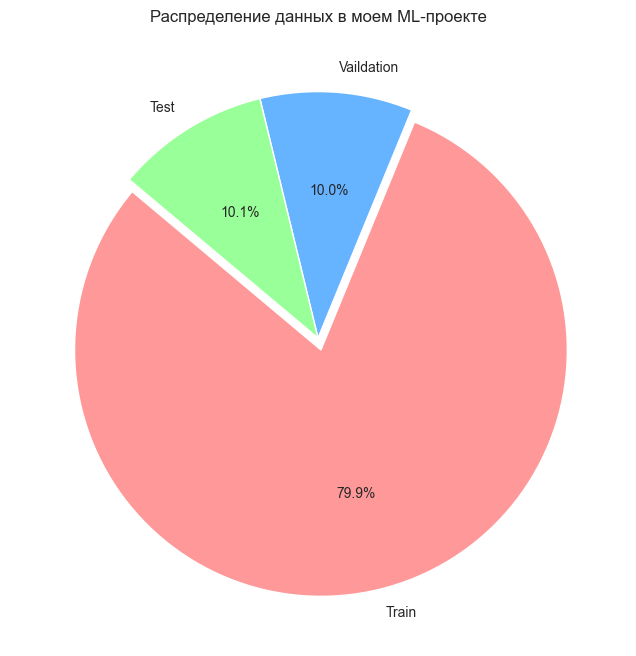

In [169]:
# visualize data distribution


labels  = ['Train','Vaildation','Test']
sizes = [round(len(X_train)),round(len(X_val)),round(len(X_test))]
colors = ['#ff9999','#66b3ff','#99ff99']

plt.figure(figsize=(8,8))

plt.pie(sizes,labels=labels,autopct='%1.1f%%',colors=colors,startangle=140,explode=(0.05,0,0))

plt.title('Распределение данных в моем ML-проекте')
plt.show()


In [164]:
def get_output_path(filename):
    return Path().resolve().parent / 'output' / filename

# save dataset data

X_train.to_csv(get_output_path('x_train.csv'),index=False),
X_val.to_csv(get_output_path('x_val.csv'),index=False),
X_test.to_csv(get_output_path('x_test.csv'),index=False),
y_train.to_csv(get_output_path('y_train.csv'),index=False),
y_val.to_csv(get_output_path('y_val.csv'),index=False),
y_test.to_csv(get_output_path('y_test.csv'),index=False)




# Preprocessing Pipeline

In [165]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score

numeric_features = ['Age', 'Fare', 'FamilySize']
categoric_features = ['Sex', 'Pclass', 'Title', 'Embarked']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categoric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categoric_transformer, categoric_features),
    ]
)


## Cross Validation

In [166]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])


scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy') # precision || recall || accuracy
print(scores)






[0.76923077 0.77622378 0.78169014 0.77464789 0.80985915]


## Hyperparameter tuning

In [167]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5],
}




grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
)


##TODO upgrade to optuna



grid_search.fit(X_train, y_train)


results = pd.DataFrame(grid_search.cv_results_)


top_results = results[['params', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score')





top_results.head(5)


,params,mean_test_score,rank_test_score
7,"{'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}",0.831429,1
6,"{'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}",0.828602,2
5,"{'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}",0.827223,3
4,"{'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}",0.824387,4
10,"{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}",0.821619,5


In [ ]:
rf1 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(max_depth=5,min_samples_split=5,n_estimators=200))
])

rf1.fit(X_train,y_train)


rf2 = Pipeline(
    [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(max_depth=5,min_samples_split=5,n_estimators=100))
    ]
)


rf2.fit(X_train,y_train)

rf3 = Pipeline(    [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(max_depth=5,min_samples_split=2,n_estimators=200))
    ])
rf3.fit(X_train,y_train)



,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## model Evaluation

In [ ]:
for model in [rf1,rf2,rf3]:
    y_pred = model.predict(X_val)

    score = accuracy_score(y_val, y_pred)
    print(f'Accuracy: {score} , Model: {model}')